replace ./nsl-kdd/NSL-KDD/index.html? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  DATASET_DIR : ./nsl-kdd/NSL-KDD
  TRAIN_FILE  : KDDTrain+.txt
  TEST_FILE   : KDDTest+.txt

PHASE 1: DATA PREPROCESSING
  Loading: ./nsl-kdd/NSL-KDD/KDDTrain+.txt
  Loading: ./nsl-kdd/NSL-KDD/KDDTest+.txt
  Training samples : 125,973
  Test samples     : 22,544
  Features selected: 20

PHASE 2: DATASET VISUALISATION


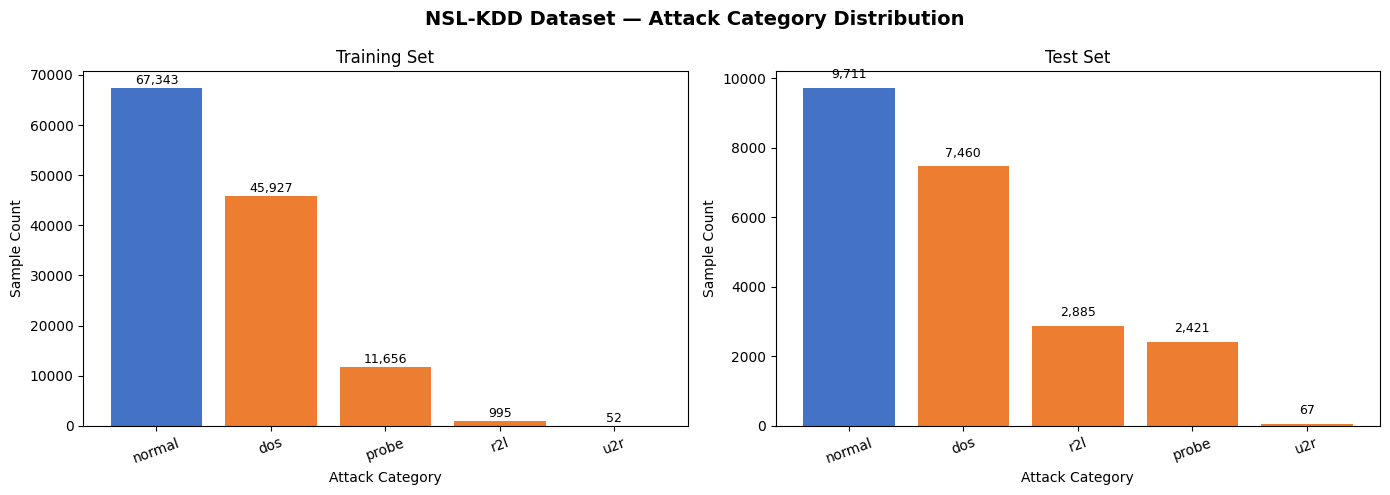

  Saved: dataset_distribution.png

PHASE 3: TRAINING DEEP LEARNING MODELS
  [Full DNN] Train time: 341.08s | Peak memory: 21205.8 KB
  [Lightweight DNN] Train time: 96.84s | Peak memory: 16065.8 KB

PHASE 4: TRAINING BASELINE MODELS (Decision Tree & SVM)
  (Baselines from Kumar & Sharma, 2019 — Literature Review)
  [Decision Tree] Train time: 0.44s | Peak memory: 7019.3 KB
  [SVM] Train time: 661.18s | Peak memory: 40421.3 KB

PHASE 5: EVALUATION

PHASE 6: PER-ATTACK-CATEGORY ANALYSIS

  Full DNN — Per-Category Results:
  Category       Count     Acc    Prec     Rec      F1
  DOS            7,460  0.8395  1.0000  0.8395  0.9128
  NORMAL         9,711  0.9726  0.0000  0.0000  0.0000
  PROBE          2,421  0.8761  1.0000  0.8761  0.9339
  R2L            2,885  0.1407  1.0000  0.1407  0.2467
  U2R               67  0.0448  1.0000  0.0448  0.0857

PHASE 7: GENERATING PLOTS


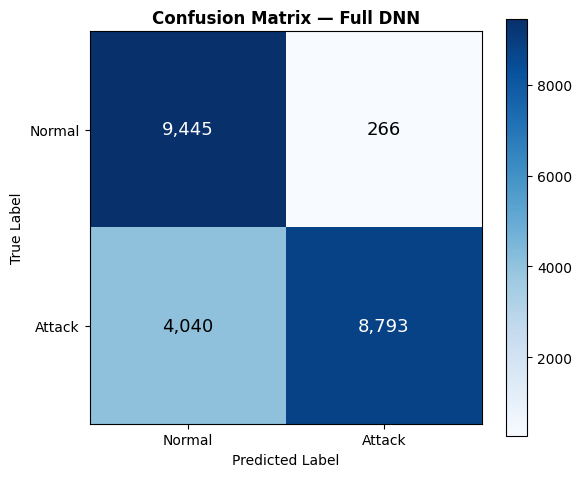

  Saved: cm_Full_DNN.png


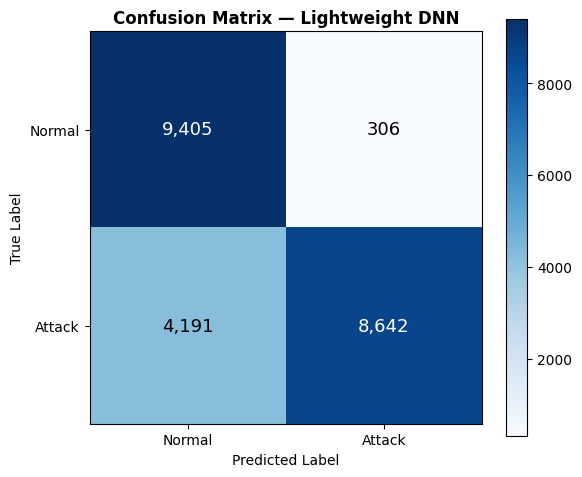

  Saved: cm_Lightweight_DNN.png


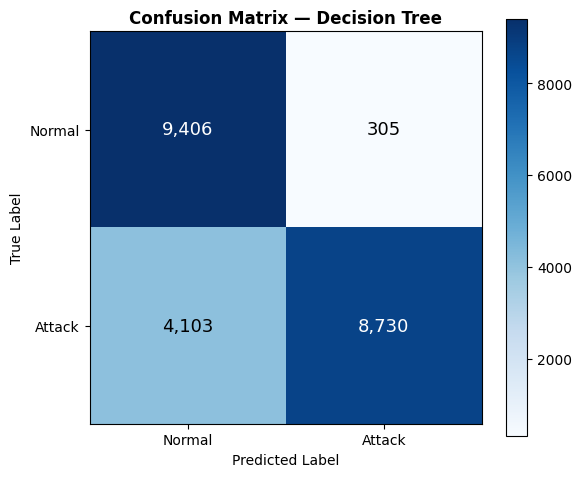

  Saved: cm_Decision_Tree.png


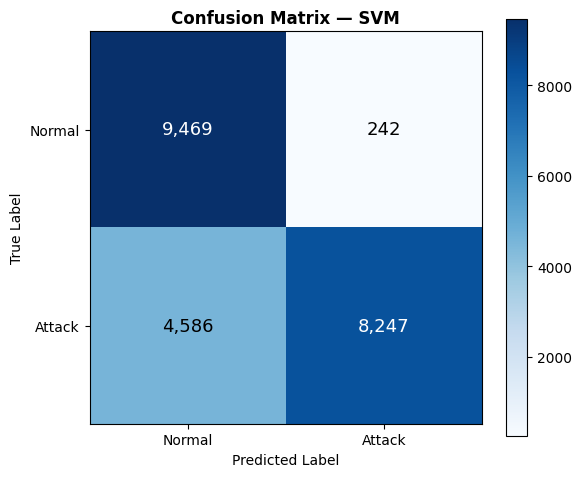

  Saved: cm_SVM.png


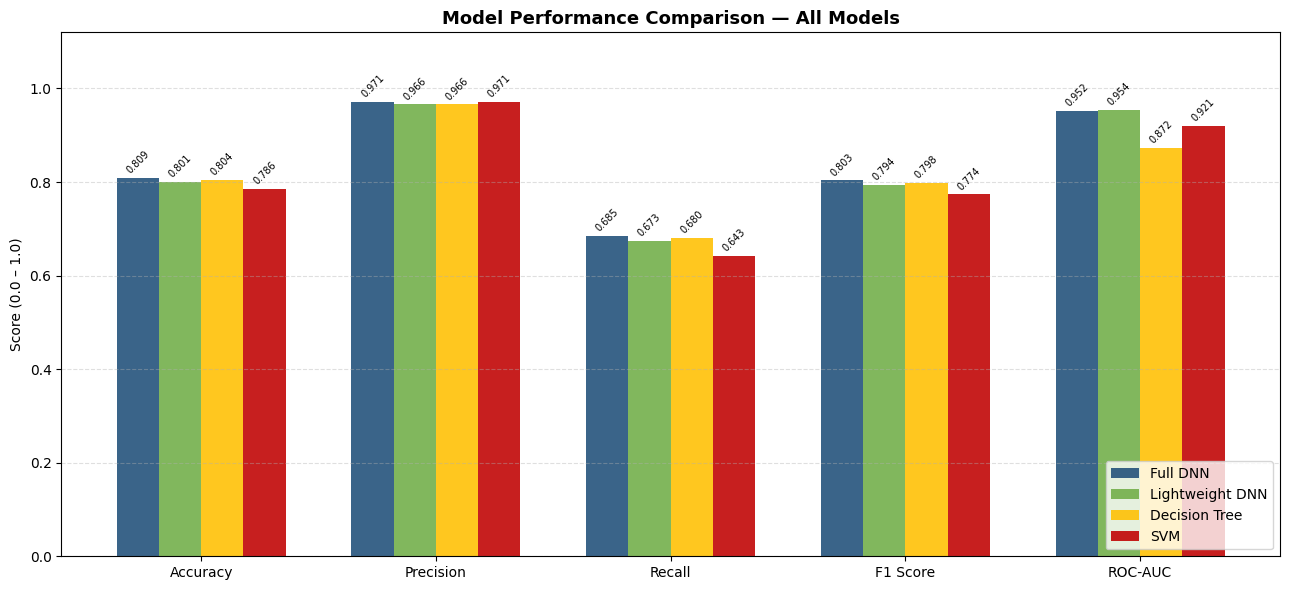

  Saved: comparison_all_models.png


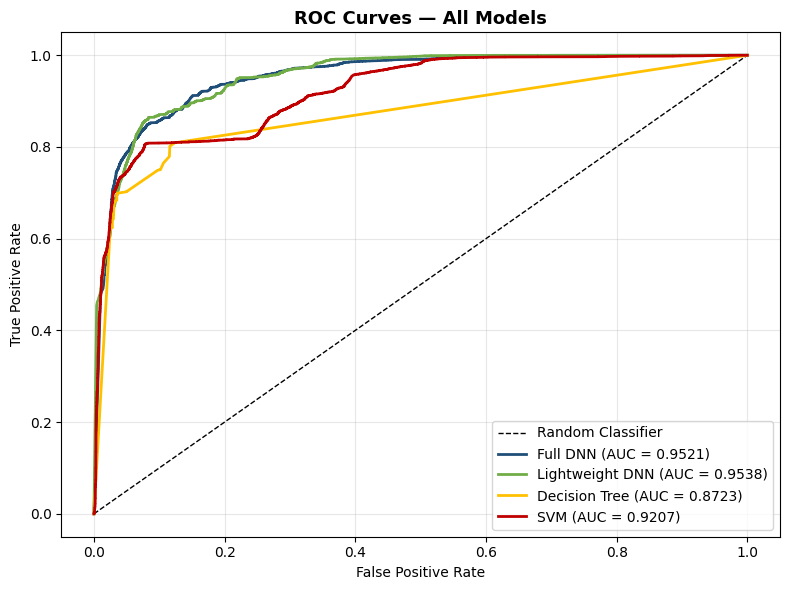

  Saved: roc_curves.png


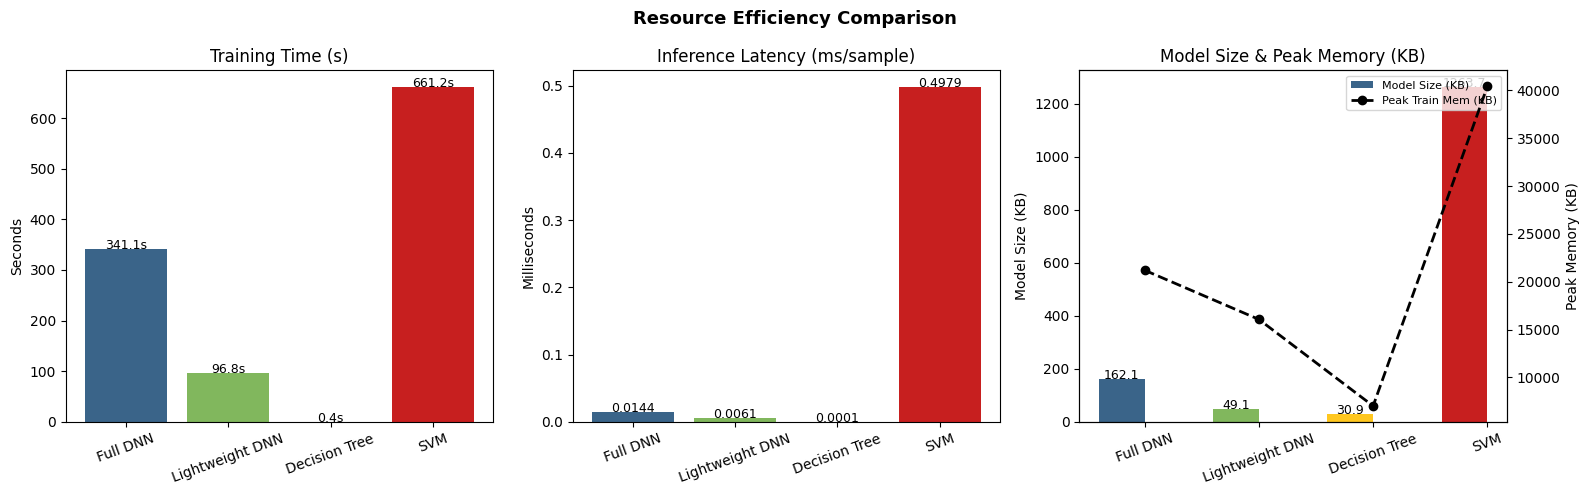

  Saved: resources_all_models.png


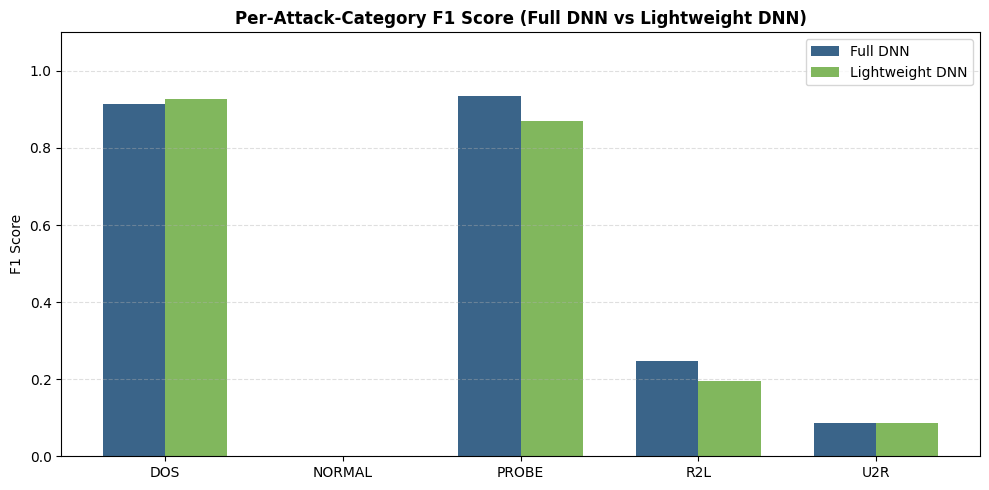

  Saved: per_category_f1.png

FINAL SUMMARY TABLE — GROUP 4 (CSC 309)
Metric                     Full DNN    Light DNN    Dec. Tree          SVM
----------------------------------------------------------------------
  Accuracy                   0.8090        0.8005        0.8045        0.7858
  Precision                  0.9706        0.9658        0.9662        0.9715
  Recall                     0.6852        0.6734        0.6803        0.6426
  F1 Score                   0.8033        0.7935        0.7984        0.7736
  ROC-AUC                    0.9521        0.9538        0.8723        0.9207
  Infer. (ms/samp)         0.014385      0.006103      0.000129      0.497875
----------------------------------------------------------------------
  Train Time (s)             341.08         96.84          0.44        661.18
  Peak Mem (KB)             21205.8       16065.8        7019.3       40421.3
  Model Size (KB)             162.1          49.1          30.9        1263.7
  DNN Param

In [ ]:
# =============================================================================
# CSC 309 PROJECT - GROUP 4 (CYBERSECURITY)
# Deep Learning-Based Intrusion Detection for Resource-Constrained Networks
# Nnamdi Azikiwe University Awka | Supervisor: Dr. Alade
# =============================================================================

# --- Imports and Setup ---

import os
import sys
import time
import tracemalloc
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, auc
)

warnings.filterwarnings('ignore')

# --- Output Directory ---
OUTPUT_DIR = 'results/plots'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Color Palette ---
COLORS = {
    'primary':  '#1f4e79',
    'accent':   '#2e75b6',
    'light':    '#bdd7ee',
    'success':  '#70ad47',
    'warning':  '#ffc000',
    'danger':   '#c00000',
    'normal':   '#4472c4',
    'attack':   '#ed7d31',
    'full':     '#1f4e79',
    'light_m':  '#70ad47',
    'dt':       '#ffc000',
    'svm':      '#c00000',
}

# =============================================================================
# SECTION 1: DATASET ACCESS
# =============================================================================

# Step 1 — Unzip the uploaded NSL-KDD.zip
!unzip -q NSL-KDD.zip -d ./nsl-kdd
DATASET_DIR = './nsl-kdd/NSL-KDD'
TRAIN_FILE  = 'KDDTrain+.txt'
TEST_FILE   = 'KDDTest+.txt'

print(f"  DATASET_DIR : {DATASET_DIR}")
print(f"  TRAIN_FILE  : {TRAIN_FILE}")
print(f"  TEST_FILE   : {TEST_FILE}")

# =============================================================================
# SECTION 2: PREPROCESSING MODULE
# =============================================================================

COLUMN_NAMES = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes',
    'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
    'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
    'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
    'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'label', 'difficulty'
]

ATTACK_MAP = {
    'normal': 'normal',
    # DoS attacks
    'back': 'dos', 'land': 'dos', 'neptune': 'dos', 'pod': 'dos',
    'smurf': 'dos', 'teardrop': 'dos', 'apache2': 'dos', 'udpstorm': 'dos',
    'processtable': 'dos', 'worm': 'dos', 'mailbomb': 'dos',
    # Probe attacks
    'satan': 'probe', 'ipsweep': 'probe', 'nmap': 'probe',
    'portsweep': 'probe', 'mscan': 'probe', 'saint': 'probe',
    # R2L attacks
    'guess_passwd': 'r2l', 'ftp_write': 'r2l', 'imap': 'r2l', 'phf': 'r2l',
    'multihop': 'r2l', 'warezmaster': 'r2l', 'warezclient': 'r2l',
    'spy': 'r2l', 'xlock': 'r2l', 'xsnoop': 'r2l', 'snmpguess': 'r2l',
    'snmpgetattack': 'r2l', 'httptunnel': 'r2l', 'sendmail': 'r2l',
    'named': 'r2l',
    # U2R attacks
    'buffer_overflow': 'u2r', 'loadmodule': 'u2r', 'rootkit': 'u2r',
    'perl': 'u2r', 'sqlattack': 'u2r', 'xterm': 'u2r', 'ps': 'u2r',
}

CATEGORICAL_COLS = ['protocol_type', 'service', 'flag']


def load_dataset(filepath, has_difficulty=True):
    cols = COLUMN_NAMES if has_difficulty else COLUMN_NAMES[:-1]
    df = pd.read_csv(filepath, header=None, names=cols)
    return df


def map_attack_labels(df):
    df = df.copy()
    df['attack_category'] = (
        df['label'].str.strip().str.lower()
        .map(lambda x: ATTACK_MAP.get(x, 'unknown'))
    )
    df['attack_category'] = df['attack_category'].replace('unknown', 'other')
    return df


def binary_label(df):
    df = df.copy()
    df['binary_label'] = df['attack_category'].apply(
        lambda x: 0 if x == 'normal' else 1
    )
    return df


def encode_categoricals(df, encoders=None, fit=True):
    df = df.copy()
    if fit:
        encoders = {}
        for col in CATEGORICAL_COLS:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            encoders[col] = le
    else:
        for col in CATEGORICAL_COLS:
            le = encoders[col]
            df[col] = df[col].astype(str).map(
                lambda x: le.transform([x])[0] if x in le.classes_ else -1
            )
    return df, encoders


def scale_features(X_train, X_test=None, scaler=None, fit=True):
    if fit:
        scaler = MinMaxScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test) if X_test is not None else None
    else:
        X_train_scaled = scaler.transform(X_train)
        X_test_scaled = scaler.transform(X_test) if X_test is not None else None
    return X_train_scaled, X_test_scaled, scaler


def select_features(X_train, y_train, X_test=None, k=20):
    selector = SelectKBest(score_func=f_classif, k=k)
    X_train_sel = selector.fit_transform(X_train, y_train)
    X_test_sel = selector.transform(X_test) if X_test is not None else None
    return X_train_sel, X_test_sel, selector


def preprocess_pipeline(train_path, test_path, output_dir='processed', n_features=20):
    os.makedirs(output_dir, exist_ok=True)

    train_df = load_dataset(train_path)
    test_df  = load_dataset(test_path)

    for df in [train_df, test_df]:
        if 'difficulty' in df.columns:
            df.drop(columns=['difficulty'], inplace=True)

    train_df = map_attack_labels(train_df)
    test_df  = map_attack_labels(test_df)
    train_df = binary_label(train_df)
    test_df  = binary_label(test_df)

    train_df, encoders = encode_categoricals(train_df, fit=True)
    test_df, _         = encode_categoricals(test_df, encoders=encoders, fit=False)

    feature_cols = [
        c for c in COLUMN_NAMES
        if c not in ['label', 'difficulty', 'attack_category', 'binary_label']
    ]

    X_train = train_df[feature_cols].values.astype(np.float32)
    y_train = train_df['binary_label'].values
    X_test  = test_df[feature_cols].values.astype(np.float32)
    y_test  = test_df['binary_label'].values

    X_train_scaled, X_test_scaled, scaler = scale_features(X_train, X_test, fit=True)
    X_train_sel, X_test_sel, selector = select_features(
        X_train_scaled, y_train, X_test_scaled, k=n_features
    )

    return {
        'X_train': X_train_sel, 'X_test': X_test_sel,
        'y_train': y_train,     'y_test':  y_test,
        'train_df': train_df,   'test_df':  test_df
    }


# =============================================================================
# SECTION 3: MODEL MODULE
# =============================================================================

MODEL_CONFIGS = {
    'full': {
        'hidden_layer_sizes': (128, 64, 32),
        'activation': 'relu', 'solver': 'adam',
        'alpha': 1e-4, 'batch_size': 256,
        'max_iter': 100, 'early_stopping': True, 'random_state': 42
    },
    'light': {
        'hidden_layer_sizes': (64, 32),
        'activation': 'relu', 'solver': 'adam',
        'alpha': 1e-3, 'batch_size': 512,
        'max_iter': 50, 'early_stopping': True, 'random_state': 42
    }
}


def build_model(variant='full'):
    return MLPClassifier(**MODEL_CONFIGS[variant])


def build_baseline_models():
    return {
        'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
        'SVM':           SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
    }


def train_model_with_memory(model, X_train, y_train, model_name='model'):
    tracemalloc.start()
    start = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - start
    _, peak_mem = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    peak_mem_kb = peak_mem / 1024
    print(f"  [{model_name}] Train time: {elapsed:.2f}s | Peak memory: {peak_mem_kb:.1f} KB")
    return model, elapsed, peak_mem_kb


def evaluate_model(model, X_test, y_test, model_name='model'):
    start = time.time()
    y_pred = model.predict(X_test)
    inference_time = time.time() - start
    per_sample_ms = (inference_time / len(X_test)) * 1000

    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_prob = model.decision_function(X_test)
    else:
        y_prob = y_pred.astype(float)

    roc_auc = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    metrics = {
        'accuracy':         accuracy_score(y_test, y_pred),
        'precision':        precision_score(y_test, y_pred, average='binary', zero_division=0),
        'recall':           recall_score(y_test, y_pred, average='binary', zero_division=0),
        'f1':               f1_score(y_test, y_pred, average='binary', zero_division=0),
        'roc_auc':          roc_auc,
        'fpr':              fpr,
        'tpr':              tpr,
        'per_sample_ms':    per_sample_ms,
        'confusion_matrix': confusion_matrix(y_test, y_pred),
    }
    return metrics, y_pred


def count_parameters(model):
    total = 0
    if hasattr(model, 'coefs_'):
        for lw in model.coefs_:      total += lw.size
        for lb in model.intercepts_: total += lb.size
    return total


def get_model_size_kb(model):
    import pickle
    serialized = pickle.dumps(model)
    return len(serialized) / 1024


def evaluate_per_category(model, test_df, X_test):
    y_pred  = model.predict(X_test)
    test_df = test_df.copy().iloc[:len(y_pred)].copy()
    test_df['predicted'] = y_pred

    results = {}
    for cat in sorted(test_df['attack_category'].unique()):
        mask        = test_df['attack_category'] == cat
        true_labels = test_df.loc[mask, 'binary_label'].values
        pred_labels = test_df.loc[mask, 'predicted'].values
        if len(true_labels) == 0:
            continue
        results[cat] = {
            'count':     len(true_labels),
            'accuracy':  accuracy_score(true_labels, pred_labels),
            'precision': precision_score(true_labels, pred_labels, zero_division=0),
            'recall':    recall_score(true_labels, pred_labels, zero_division=0),
            'f1':        f1_score(true_labels, pred_labels, zero_division=0),
        }
    return results


# =============================================================================
# SECTION 4: VISUALIZATION MODULE
# =============================================================================

def plot_dataset_distribution(train_df, test_df):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('NSL-KDD Dataset — Attack Category Distribution', fontsize=14, fontweight='bold')
    for ax, (df, title) in zip(axes, [(train_df, 'Training Set'), (test_df, 'Test Set')]):
        counts = df['attack_category'].value_counts()
        bars = ax.bar(counts.index, counts.values,
                      color=[COLORS['normal'] if i == 'normal' else COLORS['attack']
                             for i in counts.index])
        ax.set_title(title, fontsize=12)
        ax.set_xlabel('Attack Category')
        ax.set_ylabel('Sample Count')
        for bar, val in zip(bars, counts.values):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
                    f'{val:,}', ha='center', va='bottom', fontsize=9)
        ax.tick_params(axis='x', rotation=20)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'dataset_distribution.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("  Saved: dataset_distribution.png")


def plot_confusion_matrix(cm, model_name):
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap='Blues')
    plt.colorbar(im, ax=ax)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Normal', 'Attack'])
    ax.set_yticklabels(['Normal', 'Attack'])
    ax.set_xlabel('Predicted Label'); ax.set_ylabel('True Label')
    ax.set_title(f'Confusion Matrix — {model_name}', fontweight='bold')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i, j]:,}', ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=13)
    plt.tight_layout()
    safe_name = model_name.replace(' ', '_')
    plt.savefig(os.path.join(OUTPUT_DIR, f'cm_{safe_name}.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved: cm_{safe_name}.png")


def plot_model_comparison(all_metrics, model_names):
    metric_keys   = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
    model_colors  = [COLORS['full'], COLORS['light_m'], COLORS['dt'], COLORS['svm']]

    x     = np.arange(len(metric_labels))
    width = 0.18
    fig, ax = plt.subplots(figsize=(13, 6))

    for idx, (name, color) in enumerate(zip(model_names, model_colors)):
        values = [all_metrics[name][k] for k in metric_keys]
        offset = (idx - len(model_names) / 2 + 0.5) * width
        bars   = ax.bar(x + offset, values, width, label=name, color=color, alpha=0.88)
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.005,
                    f'{bar.get_height():.3f}',
                    ha='center', va='bottom', fontsize=7, rotation=45)

    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels)
    ax.set_ylabel('Score (0.0 – 1.0)')
    ax.set_ylim(0, 1.12)
    ax.set_title('Model Performance Comparison — All Models', fontweight='bold', fontsize=13)
    ax.legend(loc='lower right')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'comparison_all_models.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("  Saved: comparison_all_models.png")


def plot_roc_curves(all_metrics, model_names):
    model_colors = [COLORS['full'], COLORS['light_m'], COLORS['dt'], COLORS['svm']]
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')

    for name, color in zip(model_names, model_colors):
        m = all_metrics[name]
        ax.plot(m['fpr'], m['tpr'], color=color, lw=2,
                label=f"{name} (AUC = {m['roc_auc']:.4f})")

    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curves — All Models', fontweight='bold', fontsize=13)
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'roc_curves.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("  Saved: roc_curves.png")


def plot_resource_comparison(all_metrics, model_names, train_times, peak_mems, model_sizes_kb):
    model_colors = [COLORS['full'], COLORS['light_m'], COLORS['dt'], COLORS['svm']]
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle('Resource Efficiency Comparison', fontweight='bold', fontsize=13)

    # Panel 1 — Training Time
    axes[0].bar(model_names, train_times, color=model_colors, alpha=0.88)
    axes[0].set_title('Training Time (s)')
    axes[0].set_ylabel('Seconds')
    for i, v in enumerate(train_times):
        axes[0].text(i, v + 0.3, f'{v:.1f}s', ha='center', fontsize=9)
    axes[0].tick_params(axis='x', rotation=20)

    # Panel 2 — Inference Latency
    latencies = [all_metrics[n]['per_sample_ms'] for n in model_names]
    axes[1].bar(model_names, latencies, color=model_colors, alpha=0.88)
    axes[1].set_title('Inference Latency (ms/sample)')
    axes[1].set_ylabel('Milliseconds')
    for i, v in enumerate(latencies):
        axes[1].text(i, v + 0.0001, f'{v:.4f}', ha='center', fontsize=9)
    axes[1].tick_params(axis='x', rotation=20)

    # Panel 3 — Model Size (KB) + Peak Memory (KB)
    x         = np.arange(len(model_names))
    bar_width  = 0.4
    bars = axes[2].bar(x - 0.2, model_sizes_kb, bar_width,
                       label='Model Size (KB)', color=model_colors, alpha=0.88)
    ax2  = axes[2].twinx()
    ax2.plot(x, peak_mems, 'o--', color='black', lw=2, label='Peak Train Mem (KB)')
    ax2.set_ylabel('Peak Memory (KB)', color='black')
    axes[2].set_title('Model Size & Peak Memory (KB)')
    axes[2].set_ylabel('Model Size (KB)')
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(model_names, rotation=20)
    for bar, val in zip(bars, model_sizes_kb):
        axes[2].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.5,
                     f'{val:.1f}', ha='center', fontsize=9)
    lines1, labels1 = axes[2].get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    axes[2].legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper right')

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'resources_all_models.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("  Saved: resources_all_models.png")


def plot_per_category_performance(cat_results_full, cat_results_light, title_full, title_light):
    categories = sorted(set(list(cat_results_full.keys()) + list(cat_results_light.keys())))
    x     = np.arange(len(categories))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))
    f1_full  = [cat_results_full.get(c,  {}).get('f1', 0) for c in categories]
    f1_light = [cat_results_light.get(c, {}).get('f1', 0) for c in categories]

    ax.bar(x - width / 2, f1_full,  width, label=title_full,  color=COLORS['full'],    alpha=0.88)
    ax.bar(x + width / 2, f1_light, width, label=title_light, color=COLORS['light_m'], alpha=0.88)
    ax.set_xticks(x)
    ax.set_xticklabels([c.upper() for c in categories])
    ax.set_ylabel('F1 Score')
    ax.set_ylim(0, 1.1)
    ax.set_title('Per-Attack-Category F1 Score (Full DNN vs Lightweight DNN)', fontweight='bold')
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'per_category_f1.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("  Saved: per_category_f1.png")


# =============================================================================
# SECTION 5: EXECUTION PIPELINE
# =============================================================================

N_FEATURES = 20


def run_pipeline():

    # ── Phase 1: Preprocessing ───────────────────────────────────────────────
    print("\n" + "="*60)
    print("PHASE 1: DATA PREPROCESSING")
    print("="*60)

    if DATASET_DIR is None or TRAIN_FILE is None or TEST_FILE is None:
        print("[ERROR] Dataset path could not be resolved. Check the unzip output above.")
        return

    train_path = os.path.join(DATASET_DIR, TRAIN_FILE)
    test_path  = os.path.join(DATASET_DIR, TEST_FILE)

    print(f"  Loading: {train_path}")
    print(f"  Loading: {test_path}")

    data = preprocess_pipeline(train_path, test_path, n_features=N_FEATURES)
    print(f"  Training samples : {len(data['X_train']):,}")
    print(f"  Test samples     : {len(data['X_test']):,}")
    print(f"  Features selected: {N_FEATURES}")

    # ── Phase 2: Dataset Visualisation ───────────────────────────────────────
    print("\n" + "="*60)
    print("PHASE 2: DATASET VISUALISATION")
    print("="*60)
    plot_dataset_distribution(data['train_df'], data['test_df'])

    # ── Phase 3: Training — DNN Models ───────────────────────────────────────
    print("\n" + "="*60)
    print("PHASE 3: TRAINING DEEP LEARNING MODELS")
    print("="*60)

    model_full  = build_model('full')
    model_light = build_model('light')

    model_full,  t_full,  mem_full  = train_model_with_memory(
        model_full,  data['X_train'], data['y_train'], 'Full DNN')
    model_light, t_light, mem_light = train_model_with_memory(
        model_light, data['X_train'], data['y_train'], 'Lightweight DNN')

    # ── Phase 4: Training — Baseline Models ──────────────────────────────────
    print("\n" + "="*60)
    print("PHASE 4: TRAINING BASELINE MODELS (Decision Tree & SVM)")
    print("  (Baselines from Kumar & Sharma, 2019 — Literature Review)")
    print("="*60)

    baselines = build_baseline_models()
    model_dt  = baselines['Decision Tree']
    model_svm = baselines['SVM']

    model_dt,  t_dt,  mem_dt  = train_model_with_memory(
        model_dt,  data['X_train'], data['y_train'], 'Decision Tree')
    model_svm, t_svm, mem_svm = train_model_with_memory(
        model_svm, data['X_train'], data['y_train'], 'SVM')

    # ── Phase 5: Evaluation ───────────────────────────────────────────────────
    print("\n" + "="*60)
    print("PHASE 5: EVALUATION")
    print("="*60)

    m_full,  _ = evaluate_model(model_full,  data['X_test'], data['y_test'], 'Full DNN')
    m_light, _ = evaluate_model(model_light, data['X_test'], data['y_test'], 'Lightweight DNN')
    m_dt,    _ = evaluate_model(model_dt,    data['X_test'], data['y_test'], 'Decision Tree')
    m_svm,   _ = evaluate_model(model_svm,   data['X_test'], data['y_test'], 'SVM')

    all_metrics = {
        'Full DNN':        m_full,
        'Lightweight DNN': m_light,
        'Decision Tree':   m_dt,
        'SVM':             m_svm,
    }
    model_names = list(all_metrics.keys())
    train_times = [t_full,   t_light,   t_dt,   t_svm]
    peak_mems   = [mem_full, mem_light, mem_dt, mem_svm]
    model_sizes = [
        get_model_size_kb(model_full),
        get_model_size_kb(model_light),
        get_model_size_kb(model_dt),
        get_model_size_kb(model_svm),
    ]

    # ── Phase 6: Per-Category Analysis ────────────────────────────────────────
    print("\n" + "="*60)
    print("PHASE 6: PER-ATTACK-CATEGORY ANALYSIS")
    print("="*60)

    cat_full  = evaluate_per_category(model_full,  data['test_df'], data['X_test'])
    cat_light = evaluate_per_category(model_light, data['test_df'], data['X_test'])

    print("\n  Full DNN — Per-Category Results:")
    print(f"  {'Category':<12} {'Count':>7} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7}")
    for cat, res in sorted(cat_full.items()):
        print(f"  {cat.upper():<12} {res['count']:>7,} {res['accuracy']:>7.4f} "
              f"{res['precision']:>7.4f} {res['recall']:>7.4f} {res['f1']:>7.4f}")

    # ── Phase 7: All Visualisations ────────────────────────────────────────────
    print("\n" + "="*60)
    print("PHASE 7: GENERATING PLOTS")
    print("="*60)

    plot_confusion_matrix(m_full['confusion_matrix'],  'Full DNN')
    plot_confusion_matrix(m_light['confusion_matrix'], 'Lightweight DNN')
    plot_confusion_matrix(m_dt['confusion_matrix'],    'Decision Tree')
    plot_confusion_matrix(m_svm['confusion_matrix'],   'SVM')

    plot_model_comparison(all_metrics, model_names)
    plot_roc_curves(all_metrics, model_names)
    plot_resource_comparison(all_metrics, model_names, train_times, peak_mems, model_sizes)
    plot_per_category_performance(cat_full, cat_light, 'Full DNN', 'Lightweight DNN')

    # ── Final Summary Table ────────────────────────────────────────────────────
    print("\n" + "="*70)
    print("FINAL SUMMARY TABLE — GROUP 4 (CSC 309)")
    print("="*70)
    print(f"{'Metric':<22} {'Full DNN':>12} {'Light DNN':>12} {'Dec. Tree':>12} {'SVM':>12}")
    print("-"*70)

    for label, key in [
        ('Accuracy',         'accuracy'),
        ('Precision',        'precision'),
        ('Recall',           'recall'),
        ('F1 Score',         'f1'),
        ('ROC-AUC',          'roc_auc'),
        ('Infer. (ms/samp)', 'per_sample_ms'),
    ]:
        vals = [all_metrics[n][key] for n in model_names]
        fmt  = '{:.4f}' if key != 'per_sample_ms' else '{:.6f}'
        row  = f"  {label:<20} " + "  ".join(f"{fmt.format(v):>12}" for v in vals)
        print(row)

    print("-"*70)
    print(f"  {'Train Time (s)':<20} " +
          "  ".join(f"{v:>12.2f}" for v in train_times))
    print(f"  {'Peak Mem (KB)':<20} " +
          "  ".join(f"{v:>12.1f}" for v in peak_mems))
    print(f"  {'Model Size (KB)':<20} " +
          "  ".join(f"{v:>12.1f}" for v in model_sizes))

    params_full  = count_parameters(model_full)
    params_light = count_parameters(model_light)
    print(f"  {'DNN Parameters':<20} {params_full:>12,} {params_light:>12,}")

    print("="*70)
    print("\n  All plots saved to:", OUTPUT_DIR)
    print("  Project complete — Group 4.\n")


# ── Entry Point ────────────────────────────────────────────────────────────────
run_pipeline()